# MaxEnt 종분포모델 (Species Distribution Model) - 붉은귀거북

이 노트북은 elapid 패키지를 사용하여 붉은귀거북(Trachemys scripta elegans)의 서식지 적합성을 예측하는 MaxEnt 모델을 구현합니다.

## 데이터
- **발견 지점**: 붉은귀거북 발견 위치 929개
- **환경 변수**: 생물기후, 지형, 수문, 식생 변수

## 실행 방법

### Google Colab에서 실행
1. 이 노트북을 Google Drive에 업로드
2. Colab에서 열기
3. 런타임 > 런타임 유형 변경 > GPU 선택 (선택사항)
4. 셀을 순서대로 실행

### 로컬 환경에서 실행
1. 필요한 패키지 설치:
   ```bash
   pip install elapid rasterio geopandas matplotlib seaborn scikit-learn xarray
   ```
2. 경로 설정 셀에서 `base_path` 수정
3. 셀을 순서대로 실행

## 주의사항
- 대용량 래스터 데이터 처리 시 메모리 부족에 주의
- 미래 시나리오 예측 시 시간이 오래 걸릴 수 있음
- 결과는 `Data/outputs` 폴더에 저장됨

In [1]:
# 패키지 설치 (Google Colab에서 실행)
# 로컬 환경에서는 이 셀을 건너뛰세요

import sys
if 'google.colab' in sys.modules:
    print("Google Colab 환경 감지 - 패키지 설치 시작...")
    !pip install -q elapid rasterio geopandas matplotlib seaborn scikit-learn xarray
    print("패키지 설치 완료!")
else:
    print("로컬 환경 - 패키지 설치 건너뛰기")

로컬 환경 - 패키지 설치 건너뛰기


In [2]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 지리공간 데이터 처리
import rasterio
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import Point

# MaxEnt 모델링
from elapid import MaxentModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

# 플롯 설정
plt.rcParams['figure.figsize'] = (12, 8)

# 한글 폰트 설정
import matplotlib.font_manager as fm
try:
    # Colab/Linux 환경
    import os
    if os.path.exists('/usr/share/fonts/truetype/nanum'):
        plt.rcParams['font.family'] = 'NanumGothic'
    else:
        # 나눔 폰트 설치 (Colab)
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], 
                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        fm._load_fontmanager(try_read_cache=False)
        plt.rcParams['font.family'] = 'NanumGothic'
except:
    try:
        # Mac
        plt.rcParams['font.family'] = 'AppleGothic'
    except:
        try:
            # Windows
            plt.rcParams['font.family'] = 'Malgun Gothic'
        except:
            print("한글 폰트를 찾을 수 없습니다. 영문으로 표시됩니다.")

plt.rcParams['axes.unicode_minus'] = False

print("패키지 로드 완료!")

패키지 로드 완료!


## 1. 데이터 로드 및 전처리

In [3]:
# 환경 감지 및 경로 설정
import sys

# Google Colab 환경 감지
try:
    import google.colab
    IN_COLAB = True
    print("Google Colab 환경에서 실행 중...")
    
    # Google Drive 마운트
    from google.colab import drive
    drive.mount('/content/drive')
    
    # 데이터 경로 설정
    base_path = Path('/content/drive/MyDrive/Research/CA/Data')
except ImportError:
    IN_COLAB = False
    print("로컬 환경에서 실행 중...")
    
    # 로컬 경로 설정 (자신의 경로에 맞게 수정)
    base_path = Path('/Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data')

occurrence_file = base_path / '붉은귀거북/붉은귀거북_생태원&생물학과&GBIF.csv'
env_path = base_path / 'env/current'

print(f"데이터 경로: {base_path}")
print(f"발견 지점 파일: {occurrence_file.exists()}")
print(f"환경 변수 경로: {env_path.exists()}")

로컬 환경에서 실행 중...
데이터 경로: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data
발견 지점 파일: True
환경 변수 경로: True


In [4]:
# 붉은귀거북 발견 지점 데이터 로드
occurrence_data = pd.read_csv(occurrence_file)

print(f"총 발견 지점 수: {len(occurrence_data)}")
print(f"\n데이터 구조:\n{occurrence_data.head()}")
print(f"\n데이터 정보:\n{occurrence_data.info()}")

# 중복 제거
occurrence_data_clean = occurrence_data.drop_duplicates(subset=['decimalLongitude', 'decimalLatitude'])
print(f"\n중복 제거 후 발견 지점 수: {len(occurrence_data_clean)}")

# GeoDataFrame으로 변환
geometry = [Point(xy) for xy in zip(occurrence_data_clean['decimalLongitude'], 
                                     occurrence_data_clean['decimalLatitude'])]
occurrence_gdf = gpd.GeoDataFrame(occurrence_data_clean, 
                                  geometry=geometry, 
                                  crs='EPSG:4326')

occurrence_gdf.head()

총 발견 지점 수: 928

데이터 구조:
                     Species  decimalLongitude  decimalLatitude
0  Trachemys scripta elegans        127.107222        35.998333
1  Trachemys scripta elegans        127.128136        35.960986
2  Trachemys scripta elegans        127.170556        36.191389
3  Trachemys scripta elegans        127.143333        35.857222
4  Trachemys scripta elegans        127.290864        36.265059
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Species           928 non-null    object 
 1   decimalLongitude  928 non-null    float64
 2   decimalLatitude   928 non-null    float64
dtypes: float64(2), object(1)
memory usage: 21.9+ KB

데이터 정보:
None

중복 제거 후 발견 지점 수: 779


,Species,decimalLongitude,decimalLatitude,geometry
0,Trachemys scripta elegans,127.107222,35.998333,POINT (127.10722 35.99833)
1,Trachemys scripta elegans,127.128136,35.960986,POINT (127.12814 35.96099)
2,Trachemys scripta elegans,127.170556,36.191389,POINT (127.17056 36.19139)
3,Trachemys scripta elegans,127.143333,35.857222,POINT (127.14333 35.85722)
4,Trachemys scripta elegans,127.290864,36.265059,POINT (127.29086 36.26506)


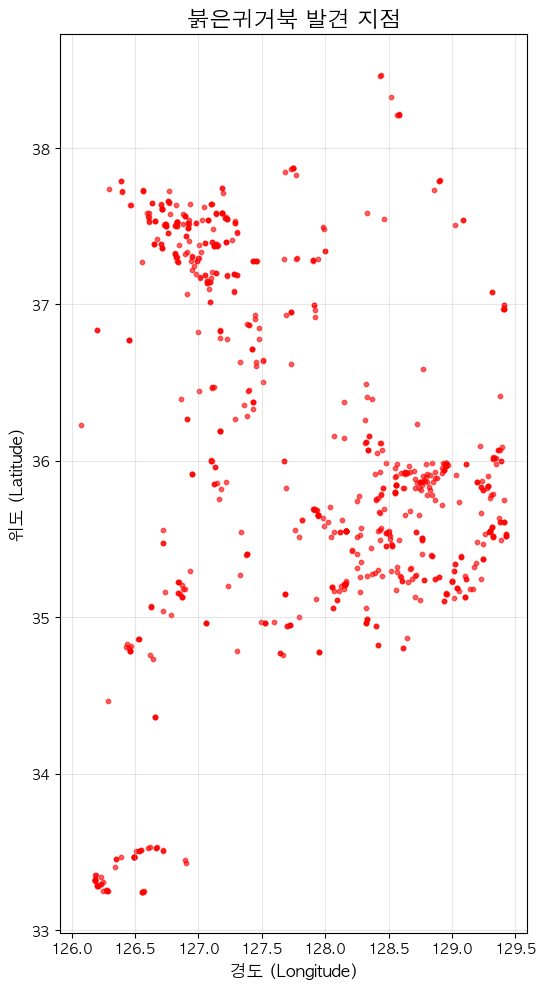

In [31]:
# 발견 지점 시각화
fig, ax = plt.subplots(figsize=(10, 10))
occurrence_gdf.plot(ax=ax, color='red', markersize=10, alpha=0.6)
ax.set_title('붉은귀거북 발견 지점', fontsize=16, fontweight='bold')
ax.set_xlabel('경도 (Longitude)', fontsize=12)
ax.set_ylabel('위도 (Latitude)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 환경 변수 로드

In [32]:
# 환경 변수 파일 목록
env_files = sorted([f for f in env_path.glob('*.asc') if not f.name.endswith('.xml')])

print(f"환경 변수 파일 수: {len(env_files)}")
print("\n환경 변수 목록:")
for i, f in enumerate(env_files, 1):
    print(f"{i}. {f.name}")

환경 변수 파일 수: 11

환경 변수 목록:
1. bio_1.asc
2. bio_12.asc
3. bio_13.asc
4. bio_14.asc
5. bio_2.asc
6. bio_4.asc
7. ele.asc
8. lake.asc
9. ndvi.asc
10. river.asc
11. slope.asc


In [33]:
# 환경 변수 래스터 데이터를 딕셔너리로 로드
env_rasters = {}
env_arrays = {}

for env_file in env_files:
    var_name = env_file.stem  # 파일명에서 확장자 제거
    
    with rasterio.open(env_file) as src:
        env_rasters[var_name] = src.read(1)  # 첫 번째 밴드 읽기
        env_arrays[var_name] = {
            'data': src.read(1),
            'transform': src.transform,
            'crs': src.crs,
            'bounds': src.bounds,
            'nodata': src.nodata
        }
        
        print(f"{var_name}: shape={src.shape}, dtype={src.dtypes[0]}")

print(f"\n총 {len(env_rasters)}개의 환경 변수 로드 완료!")

bio_1: shape=(660, 872), dtype=float32
bio_12: shape=(660, 872), dtype=int32
bio_13: shape=(660, 872), dtype=int32
bio_14: shape=(660, 872), dtype=int32
bio_2: shape=(660, 872), dtype=float32
bio_4: shape=(660, 872), dtype=float32
ele: shape=(660, 872), dtype=int32
lake: shape=(660, 872), dtype=float32
ndvi: shape=(660, 872), dtype=int32
river: shape=(660, 872), dtype=float32
slope: shape=(660, 872), dtype=float32

총 11개의 환경 변수 로드 완료!


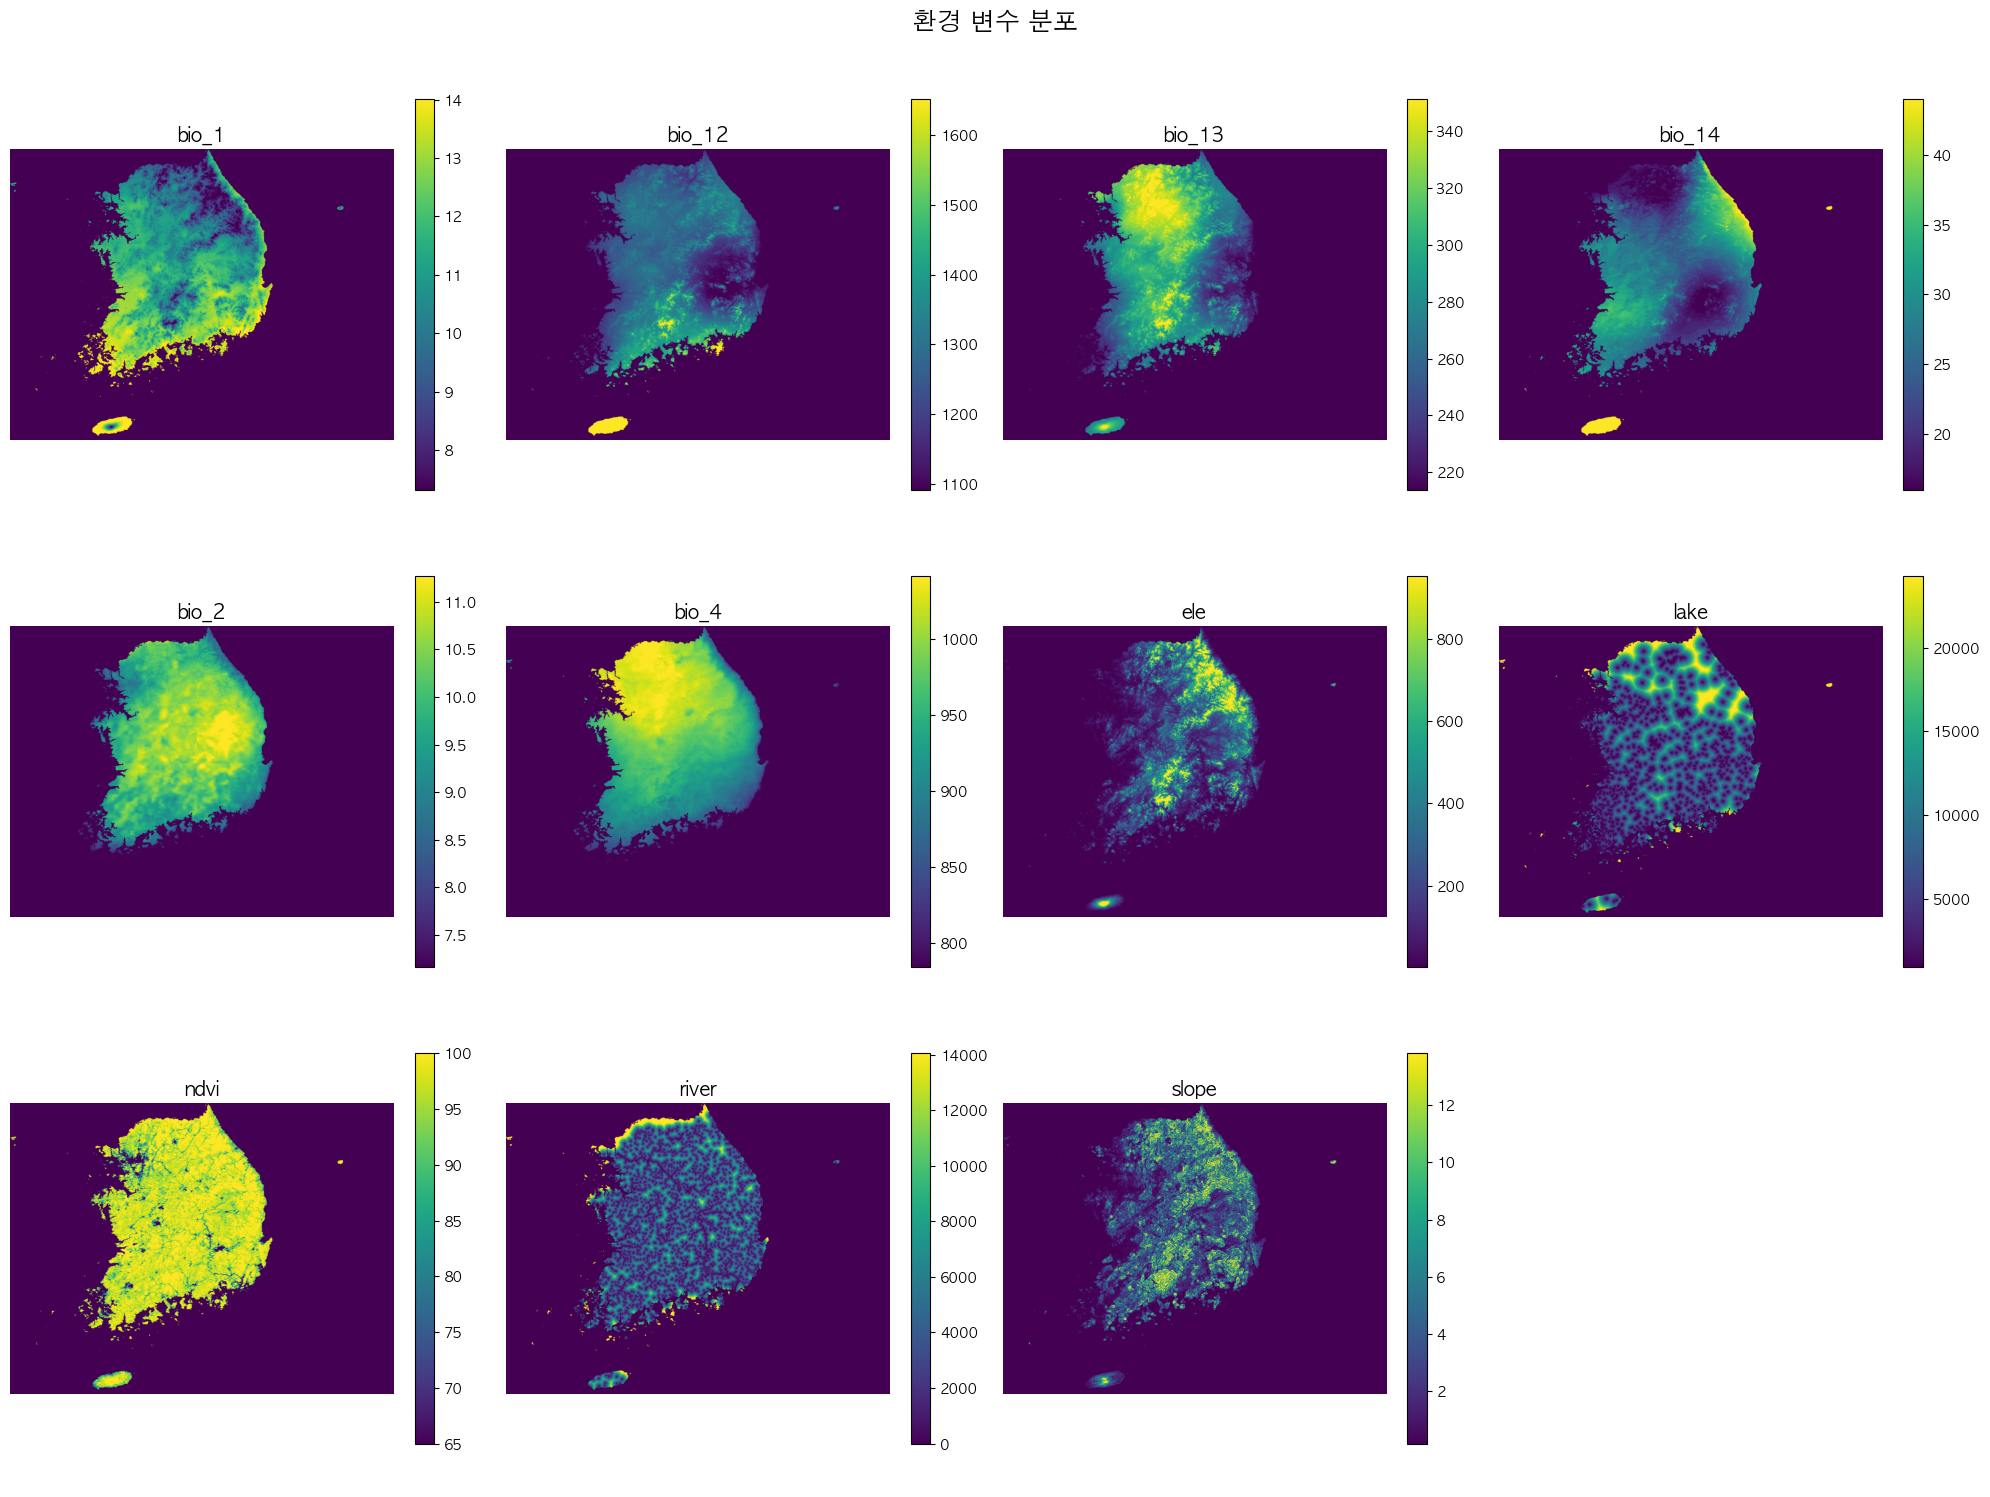

In [34]:
# 환경 변수 시각화
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, (var_name, var_data) in enumerate(env_rasters.items()):
    if idx < len(axes):
        # 유효한 데이터만 추출 (NoData 제외)
        valid_data = var_data[~np.isnan(var_data) & (var_data > -9000)]
        
        # 2번째와 98번째 백분위수 계산
        vmin = np.percentile(valid_data, 2)
        vmax = np.percentile(valid_data, 98)
        
        im = axes[idx].imshow(var_data, cmap='viridis', vmin=vmin, vmax=vmax)
        axes[idx].set_title(var_name, fontsize=14, fontweight='bold')
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046)

# 남은 subplot 숨기기
for idx in range(len(env_rasters), len(axes)):
    axes[idx].axis('off')

plt.suptitle('환경 변수 분포', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 3. MaxEnt 모델 데이터 준비 및 학습

In [35]:
# elapid를 위한 환경 변수 스택 생성
# 모든 래스터를 하나의 3D 배열로 결합 (변수, 행, 열)
env_stack = np.stack([env_rasters[var] for var in sorted(env_rasters.keys())])
var_names = sorted(env_rasters.keys())

print(f"환경 변수 스택 shape: {env_stack.shape}")
print(f"변수 순서: {var_names}")

# 첫 번째 환경 변수의 메타데이터 사용 (모든 래스터가 동일한 grid를 가진다고 가정)
first_var = env_files[0]
with rasterio.open(first_var) as src:
    transform = src.transform
    crs = src.crs
    
print(f"\nCRS: {crs}")
print(f"Transform: {transform}")

환경 변수 스택 shape: (11, 660, 872)
변수 순서: ['bio_1', 'bio_12', 'bio_13', 'bio_14', 'bio_2', 'bio_4', 'ele', 'lake', 'ndvi', 'river', 'slope']

CRS: None
Transform: | 0.01, 0.00, 124.61|
| 0.00,-0.01, 38.61|
| 0.00, 0.00, 1.00|


In [36]:
# 발견 지점에서 환경 변수 값 추출
# 좌표를 픽셀 인덱스로 변환
from rasterio.transform import rowcol

coords = list(zip(occurrence_gdf['decimalLongitude'], occurrence_gdf['decimalLatitude']))

# 각 발견 지점에서 환경 변수 값 추출
presence_data = []

for lon, lat in coords:
    row, col = rowcol(transform, lon, lat)
    
    # 범위 체크
    if 0 <= row < env_stack.shape[1] and 0 <= col < env_stack.shape[2]:
        values = env_stack[:, row, col]
        # NoData 값이 없는지 확인 (일반적으로 -9999 또는 매우 큰 값)
        if not np.any(np.isnan(values)) and not np.any(values < -9000):
            point_data = {'longitude': lon, 'latitude': lat}
            for i, var_name in enumerate(var_names):
                point_data[var_name] = values[i]
            presence_data.append(point_data)

presence_df = pd.DataFrame(presence_data)
print(f"유효한 발견 지점 수: {len(presence_df)} / {len(occurrence_gdf)}")
print(f"\n발견 지점 환경 변수 샘플:\n{presence_df.head()}")
print(f"\n기본 통계:\n{presence_df.describe()}")

유효한 발견 지점 수: 748 / 779

발견 지점 환경 변수 샘플:
    longitude   latitude     bio_1  bio_12  bio_13  bio_14     bio_2  \
0  127.107222  35.998333  12.61667  1268.0   289.0    29.0  10.71667   
1  127.128136  35.960986  13.00833  1274.0   290.0    31.0  11.10000   
2  127.170556  36.191389  12.44167  1286.0   296.0    30.0  10.66667   
3  127.143333  35.857222  13.08333  1273.0   288.0    31.0  10.85000   
4  127.290864  36.265059  11.83750  1314.0   305.0    29.0  10.69167   

        bio_4    ele         lake   ndvi        river     slope  
0  966.940674   51.0  7479.055176   93.0  2933.525879  1.330887  
1  970.304077   34.0  8400.341797   72.0  4638.312988  0.212065  
2  977.475525   27.0   927.662476  100.0  4638.312988  1.190198  
3  973.910400   50.0  3935.739014   93.0  2074.315918  0.286718  
4  984.849182  127.0  2074.315918   96.0  5642.750977  1.328657  

기본 통계:
        longitude    latitude       bio_1       bio_12      bio_13  \
count  748.000000  748.000000  748.000000   748.00000

In [37]:
# MaxEnt 모델 학습
# elapid는 presence-only 데이터로 작동하며, 학습 시 background points를 수동 생성

# 환경 변수만 추출 (좌표 제외)
X_presence = presence_df[var_names].values

# MaxEnt 모델 초기화
maxent_model = MaxentModel(
    feature_types=['linear', 'quadratic', 'hinge'],  # MaxEnt feature types
    tau=0.5,  # regularization parameter (0-1, 높을수록 더 smooth)
    clamp=True,  # clamp predictions to training range
    class_weights=100,  # presence:background 가중치 비율
    n_cpus=4  # 병렬 처리 CPU 수
)

print("MaxEnt 모델 학습 시작...")
print(f"- Presence points: {len(X_presence)}")
print(f"- Features: {var_names}")
print(f"- Feature types: linear, quadratic, hinge")

# Background points 수동 생성 (약 10,000개)
np.random.seed(42)
n_background = 10000

# 환경 변수 스택에서 유효한 픽셀 선택
valid_mask = np.all(~np.isnan(env_stack) & (env_stack > -9000), axis=0)
valid_indices = np.argwhere(valid_mask)

# 랜덤하게 background points 선택
bg_indices = valid_indices[np.random.choice(len(valid_indices), n_background, replace=False)]
X_background = env_stack[:, bg_indices[:, 0], bg_indices[:, 1]].T

print(f"- Background points: {len(X_background)}")

# Presence (1)와 Background (0) 데이터 결합
X_combined = np.vstack([X_presence, X_background])
y_combined = np.hstack([np.ones(len(X_presence)), np.zeros(len(X_background))])

print(f"\nCombined dataset: {len(X_combined)} samples")

# 모델 학습
maxent_model.fit(
    x=X_combined,
    y=y_combined,
    sample_weight=None
)

print("\nMaxEnt 모델 학습 완료!")
if hasattr(maxent_model, 'n_features_in_'):
    print(f"- Number of features: {maxent_model.n_features_in_}")
else:
    print(f"- Model trained successfully")

MaxEnt 모델 학습 시작...
- Presence points: 748
- Features: ['bio_1', 'bio_12', 'bio_13', 'bio_14', 'bio_2', 'bio_4', 'ele', 'lake', 'ndvi', 'river', 'slope']
- Feature types: linear, quadratic, hinge
- Background points: 10000

Combined dataset: 10748 samples

MaxEnt 모델 학습 완료!
- Model trained successfully


## 4. 모델 평가

In [38]:
# 변수 중요도 분석
# elapid MaxEnt는 sklearn LogisticRegression을 기반으로 함

try:
    # MaxentModel의 내부 estimator 확인
    if hasattr(maxent_model, 'estimator_'):
        estimator = maxent_model.estimator_
        
        # 변환된 feature 이름 확인 (linear, quadratic, hinge 변환 후)
        if hasattr(maxent_model, 'feature_names_in_'):
            feature_count = maxent_model.n_features_in_
            print(f"원본 변수 수: {len(var_names)}")
            print(f"변환 후 feature 수: {feature_count}")
        
        # 계수 추출
        if hasattr(estimator, 'coef_'):
            coefficients = estimator.coef_[0]
            
            # 원본 변수별로 계수를 그룹화 (linear, quadratic, hinge 합산)
            # elapid는 각 변수에 대해 여러 feature를 생성하므로 이를 그룹화
            n_vars = len(var_names)
            var_importance_dict = {}
            
            # 간단한 방법: 각 변수에 해당하는 feature들의 중요도를 합산
            # feature는 순서대로 [var1_linear, var1_quad, var1_hinge, var2_linear, ...]
            features_per_var = len(coefficients) // n_vars
            
            for i, var in enumerate(var_names):
                start_idx = i * features_per_var
                end_idx = (i + 1) * features_per_var
                var_coefs = coefficients[start_idx:end_idx]
                # 절대값의 합으로 중요도 계산
                importance = np.sum(np.abs(var_coefs))
                var_importance_dict[var] = importance
            
            # DataFrame으로 정리
            var_importance = pd.DataFrame({
                'Variable': list(var_importance_dict.keys()),
                'Importance': list(var_importance_dict.values())
            }).sort_values('Importance', ascending=False)
            
            print("\n변수 중요도:")
            print(var_importance.to_string(index=False))
            
            # 시각화
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.barh(var_importance['Variable'], var_importance['Importance'], 
                   color='steelblue', alpha=0.7)
            ax.set_xlabel('중요도 (Importance)', fontsize=12)
            ax.set_ylabel('환경 변수', fontsize=12)
            ax.set_title('MaxEnt 모델 변수 중요도', fontsize=14, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("모델 계수를 찾을 수 없습니다.")
    else:
        print("모델이 아직 학습되지 않았습니다.")
        
except Exception as e:
    print(f"변수 중요도 분석 중 오류 발생: {e}")
    print("\n대체 방법: Permutation importance 사용")
    
    # Permutation importance로 대체
    from sklearn.inspection import permutation_importance
    
    # 테스트 데이터 준비 (presence + background)
    perm_result = permutation_importance(
        maxent_model.estimator_, 
        X_combined, 
        y_combined, 
        n_repeats=10,
        random_state=42,
        scoring='roc_auc'
    )
    
    # 원본 변수 수에 맞게 중요도 재계산
    n_vars = len(var_names)
    features_per_var = X_combined.shape[1] // n_vars
    
    var_perm_importance = []
    for i in range(n_vars):
        start_idx = i * features_per_var
        end_idx = (i + 1) * features_per_var
        importance = np.mean(perm_result.importances_mean[start_idx:end_idx])
        var_perm_importance.append(importance)
    
    var_importance = pd.DataFrame({
        'Variable': var_names,
        'Importance': var_perm_importance
    }).sort_values('Importance', ascending=False)
    
    print("\nPermutation Importance:")
    print(var_importance.to_string(index=False))
    
    # 시각화
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(var_importance['Variable'], var_importance['Importance'], 
           color='steelblue', alpha=0.7)
    ax.set_xlabel('Permutation Importance', fontsize=12)
    ax.set_ylabel('환경 변수', fontsize=12)
    ax.set_title('MaxEnt 모델 변수 중요도', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

모델이 아직 학습되지 않았습니다.


In [39]:
# 모델 성능 평가 (Cross-validation)
from sklearn.model_selection import cross_val_score

# AUC score 계산 (5-fold cross-validation)
print("5-Fold Cross-Validation 수행 중...")

# background points 생성
np.random.seed(42)
n_background = 10000

# 환경 변수 스택에서 유효한 픽셀 선택
valid_mask = np.all(~np.isnan(env_stack) & (env_stack > -9000), axis=0)
valid_indices = np.argwhere(valid_mask)

# 랜덤하게 background points 선택
bg_indices = valid_indices[np.random.choice(len(valid_indices), n_background, replace=False)]
X_background = env_stack[:, bg_indices[:, 0], bg_indices[:, 1]].T

# Presence (1)와 Background (0) 데이터 결합
X_combined = np.vstack([X_presence, X_background])
y_combined = np.hstack([np.ones(len(X_presence)), np.zeros(len(X_background))])

print(f"Combined dataset: {len(X_combined)} samples")
print(f"  - Presence: {np.sum(y_combined == 1)}")
print(f"  - Background: {np.sum(y_combined == 0)}")

# Cross-validation으로 AUC 계산
cv_scores = cross_val_score(
    maxent_model.estimator, 
    X_combined, 
    y_combined, 
    cv=5, 
    scoring='roc_auc'
)

print(f"\nCross-Validation AUC Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

5-Fold Cross-Validation 수행 중...
Combined dataset: 10748 samples
  - Presence: 748
  - Background: 10000

Cross-Validation AUC Scores:
  Fold 1: 0.8394
  Fold 2: 0.8555
  Fold 3: 0.8612
  Fold 4: 0.8116
  Fold 5: 0.8134

Mean AUC: 0.8362 (+/- 0.0413)


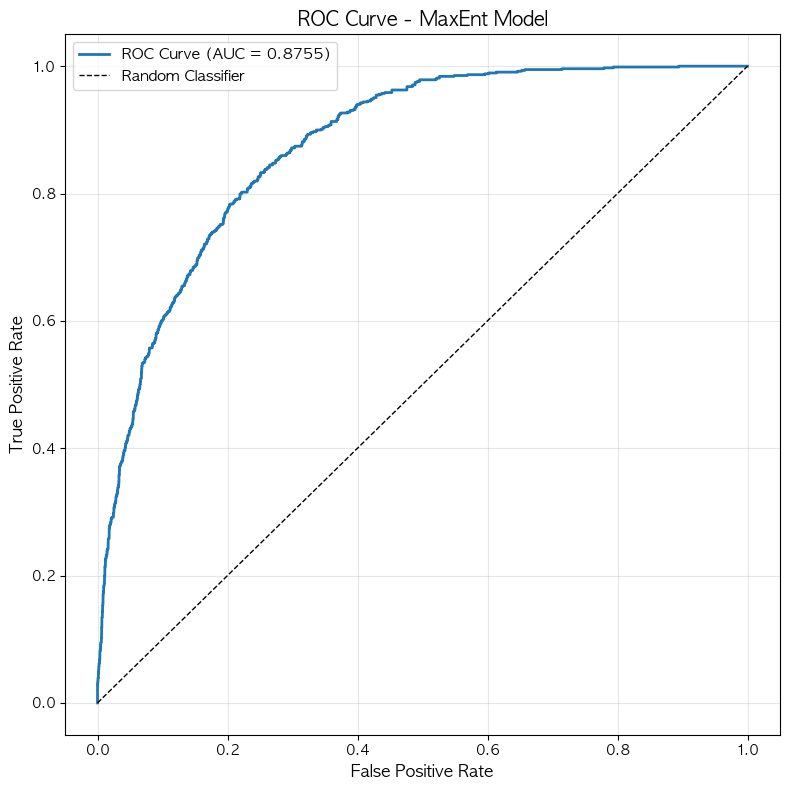

In [40]:
# ROC Curve 그리기
y_pred_proba = maxent_model.predict_proba(X_combined)[:, 1]
fpr, tpr, thresholds = roc_curve(y_combined, y_pred_proba)
auc_score = roc_auc_score(y_combined, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - MaxEnt Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 서식지 적합성 예측

In [41]:
# 전체 지역에 대한 서식지 적합성 예측
print("서식지 적합성 예측 중...")

# 환경 변수 스택을 2D 배열로 재구성 (픽셀, 변수)
n_vars, n_rows, n_cols = env_stack.shape
X_predict = env_stack.reshape(n_vars, -1).T

# NoData 처리
valid_pixels = np.all(~np.isnan(X_predict) & (X_predict > -9000), axis=1)

# 예측 배열 초기화
predictions = np.full(n_rows * n_cols, np.nan)

# 유효한 픽셀에 대해서만 예측
if np.any(valid_pixels):
    X_valid = X_predict[valid_pixels]
    pred_valid = maxent_model.predict_proba(X_valid)[:, 1]
    predictions[valid_pixels] = pred_valid

# 2D 배열로 재구성
suitability_map = predictions.reshape(n_rows, n_cols)

print(f"예측 완료!")
print(f"  - 유효 픽셀: {np.sum(valid_pixels):,} / {len(predictions):,}")
print(f"  - 적합성 범위: {np.nanmin(suitability_map):.4f} - {np.nanmax(suitability_map):.4f}")

서식지 적합성 예측 중...
예측 완료!
  - 유효 픽셀: 140,408 / 575,520
  - 적합성 범위: 0.0000 - 1.0000


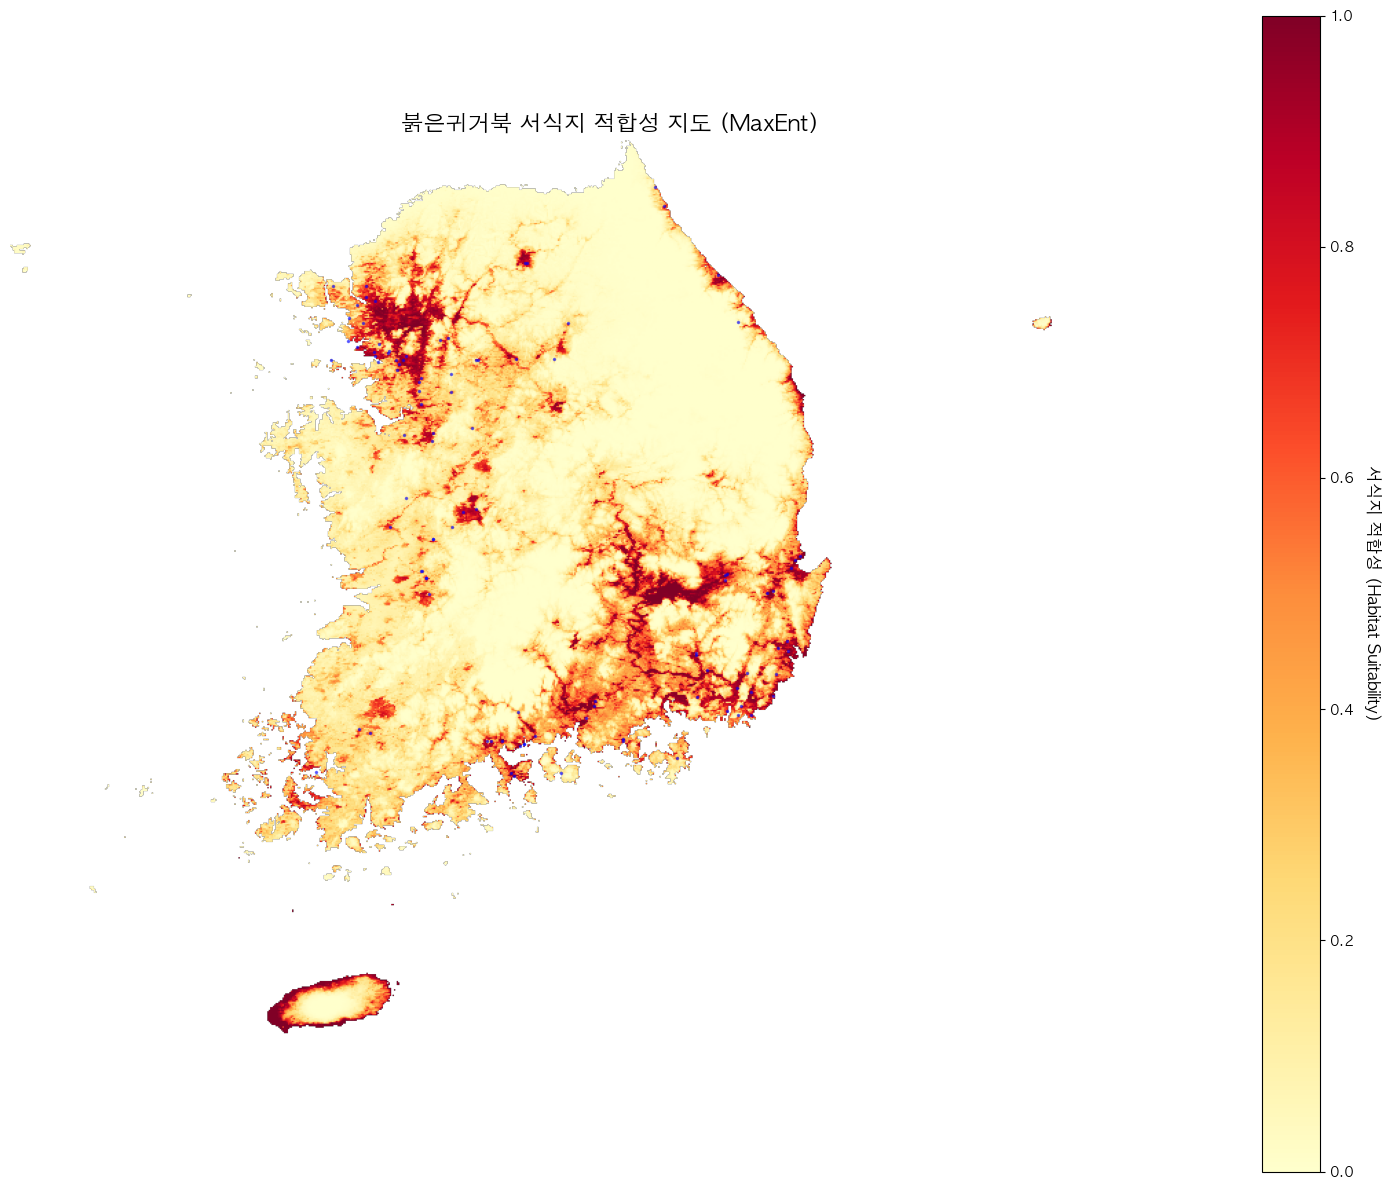

In [42]:
# 서식지 적합성 지도 시각화
fig, ax = plt.subplots(figsize=(14, 12))

# 적합성 지도 표시
im = ax.imshow(suitability_map, cmap='YlOrRd', vmin=0, vmax=1)

# 발견 지점 overlay
# 좌표를 픽셀 인덱스로 변환하여 표시
for lon, lat in zip(occurrence_gdf['decimalLongitude'][:100],  # 처음 100개만 표시
                     occurrence_gdf['decimalLatitude'][:100]):
    row, col = rowcol(transform, lon, lat)
    if 0 <= row < n_rows and 0 <= col < n_cols:
        ax.plot(col, row, 'b.', markersize=3, alpha=0.5)

ax.set_title('붉은귀거북 서식지 적합성 지도 (MaxEnt)', fontsize=16, fontweight='bold')
ax.axis('off')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('서식지 적합성 (Habitat Suitability)', fontsize=12, rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

서식지 적합성 등급별 분포:
매우 낮음    95915
낮음       21729
보통       10654
높음        5760
매우 높음     6350
Name: count, dtype: int64

전체 비율:
  매우 낮음: 68.31%
  낮음: 15.48%
  보통: 7.59%
  높음: 4.10%
  매우 높음: 4.52%


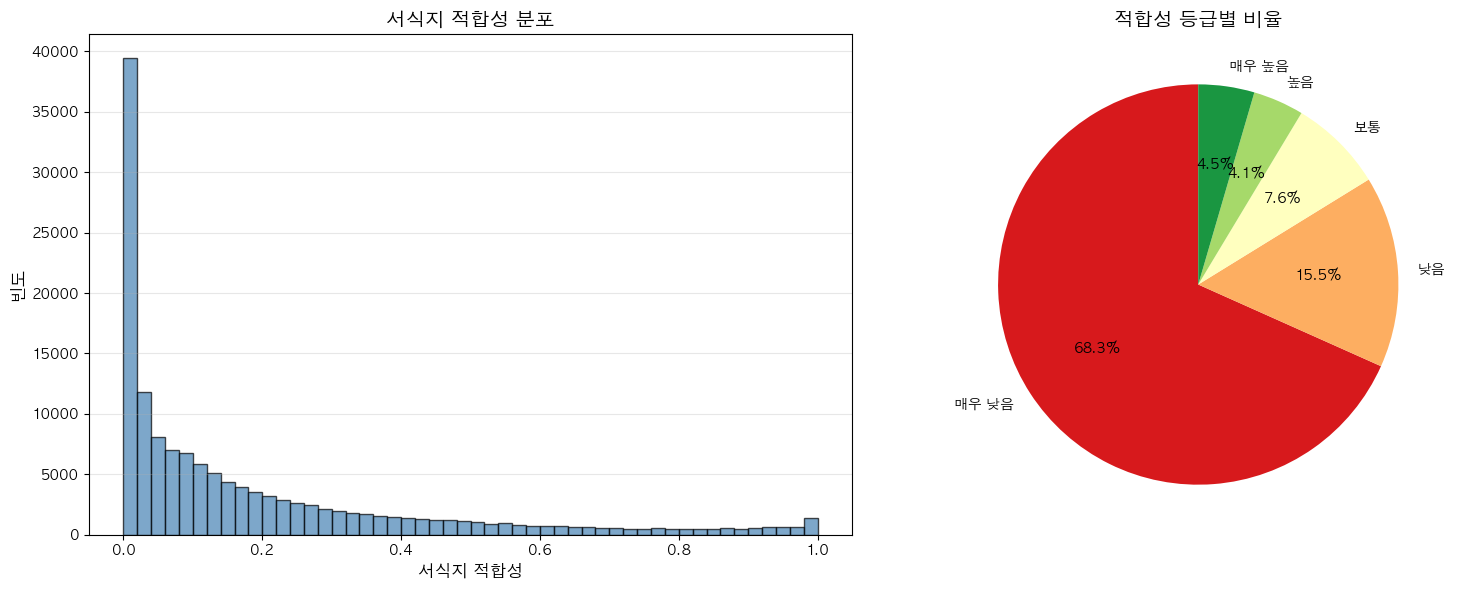

In [43]:
# 적합성 등급별 분포
suitability_classes = pd.cut(
    predictions[valid_pixels], 
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['매우 낮음', '낮음', '보통', '높음', '매우 높음']
)

class_counts = suitability_classes.value_counts().sort_index()

print("서식지 적합성 등급별 분포:")
print(class_counts)
print(f"\n전체 비율:")
for cls, count in class_counts.items():
    percentage = (count / len(suitability_classes)) * 100
    print(f"  {cls}: {percentage:.2f}%")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 히스토그램
ax1.hist(predictions[valid_pixels], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('서식지 적합성', fontsize=12)
ax1.set_ylabel('빈도', fontsize=12)
ax1.set_title('서식지 적합성 분포', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 파이 차트
colors_pie = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
ax2.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
        colors=colors_pie, startangle=90)
ax2.set_title('적합성 등급별 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. 결과 저장

In [ ]:
# 서식지 적합성 지도를 GeoTIFF로 저장
output_path = base_path / 'outputs' / 'SDM_tif'
output_path.mkdir(parents=True, exist_ok=True)

output_file = output_path / 'suitability_map_current.tif'

# 메타데이터 준비
with rasterio.open(env_files[0]) as src:
    meta = src.meta.copy()
    meta.update({
        'dtype': 'float32',
        'nodata': -9999,
        'compress': 'lzw'
    })

# GeoTIFF 저장
with rasterio.open(output_file, 'w', **meta) as dst:
    # NaN을 NoData 값으로 변환
    output_array = suitability_map.copy()
    output_array[np.isnan(output_array)] = -9999
    dst.write(output_array.astype('float32'), 1)

print(f"서식지 적합성 지도 저장 완료: {output_file}")

# 변수 중요도를 CSV로 저장
if 'var_importance' in locals():
    importance_file = output_path / 'variable_importance.csv'
    var_importance.to_csv(importance_file, index=False, encoding='utf-8-sig')
    print(f"변수 중요도 저장 완료: {importance_file}")

In [45]:
# 모델 객체 저장 (향후 미래 시나리오 예측에 재사용)
import pickle

model_file = output_path / 'maxent_model.pkl'
with open(model_file, 'wb') as f:
    pickle.dump(maxent_model, f)

print(f"MaxEnt 모델 저장 완료: {model_file}")

# 환경 변수 정보 저장
env_info = {
    'variable_names': var_names,
    'transform': transform,
    'crs': str(crs),
    'shape': (n_rows, n_cols)
}

info_file = output_path / 'env_info.pkl'
with open(info_file, 'wb') as f:
    pickle.dump(env_info, f)

print(f"환경 변수 정보 저장 완료: {info_file}")

MaxEnt 모델 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/maxent_model.pkl
환경 변수 정보 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/env_info.pkl


## 7. (선택) 미래 기후 시나리오 예측

저장된 모델을 사용하여 미래 기후 시나리오(SSP126, SSP245, SSP585)에서의 서식지 적합성을 예측할 수 있습니다.

In [46]:
# 미래 시나리오 예측 함수
def predict_future_scenario(scenario='ssp126_2030'):
    """
    미래 기후 시나리오에서 서식지 적합성 예측
    
    Parameters:
    -----------
    scenario : str
        예측할 시나리오 (예: 'ssp126_2030', 'ssp245_2050', 'ssp585_2090')
    """
    print(f"\n=== {scenario} 시나리오 예측 ===")
    
    # 미래 환경 변수 로드
    future_env_path = base_path / f'env/{scenario}'
    
    if not future_env_path.exists():
        print(f"오류: {future_env_path} 경로를 찾을 수 없습니다.")
        return None, None
    
    future_env_files = sorted([f for f in future_env_path.glob('*.asc') 
                               if not f.name.endswith('.xml')])
    
    print(f"환경 변수 파일 수: {len(future_env_files)}")
    
    # 환경 변수 로드 (학습 시와 동일한 변수만)
    future_env_rasters = {}
    for env_file in future_env_files:
        var_name = env_file.stem
        if var_name in var_names:  # 모델 학습에 사용된 변수만 로드
            with rasterio.open(env_file) as src:
                future_env_rasters[var_name] = src.read(1)
    
    # 누락된 변수 확인
    missing_vars = set(var_names) - set(future_env_rasters.keys())
    if missing_vars:
        print(f"경고: 다음 변수를 찾을 수 없습니다: {missing_vars}")
        print("현재 시나리오의 해당 변수를 사용합니다.")
        for var in missing_vars:
            future_env_rasters[var] = env_rasters[var]
    
    # 환경 변수 스택 생성 (학습 시와 동일한 순서로!)
    future_env_stack = np.stack([future_env_rasters[var] for var in var_names])
    
    print(f"미래 환경 변수 스택 shape: {future_env_stack.shape}")
    
    # 예측 데이터 준비
    n_future_vars, n_future_rows, n_future_cols = future_env_stack.shape
    X_future = future_env_stack.reshape(n_future_vars, -1).T
    valid_future = np.all(~np.isnan(X_future) & (X_future > -9000), axis=1)
    
    print(f"유효한 픽셀: {np.sum(valid_future):,}")
    
    # 예측
    future_predictions = np.full(n_future_rows * n_future_cols, np.nan)
    if np.any(valid_future):
        X_valid_future = X_future[valid_future]
        pred_future = maxent_model.predict_proba(X_valid_future)[:, 1]
        future_predictions[valid_future] = pred_future
    
    # 2D 배열로 재구성
    future_suitability_map = future_predictions.reshape(n_future_rows, n_future_cols)
    
    # 결과 저장
    future_output_file = output_path / f'suitability_map_{scenario}.tif'
    
    # 메타데이터 준비
    with rasterio.open(future_env_files[0]) as src:
        future_meta = src.meta.copy()
        future_meta.update({
            'dtype': 'float32',
            'nodata': -9999,
            'compress': 'lzw'
        })
    
    with rasterio.open(future_output_file, 'w', **future_meta) as dst:
        output_array = future_suitability_map.copy()
        output_array[np.isnan(output_array)] = -9999
        dst.write(output_array.astype('float32'), 1)
    
    print(f"미래 적합성 지도 저장 완료: {future_output_file}")
    
    # 현재와 미래 비교
    diff_map = future_suitability_map - suitability_map
    
    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # 현재
    im1 = axes[0].imshow(suitability_map, cmap='YlOrRd', vmin=0, vmax=1)
    axes[0].set_title('현재 (Current)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], fraction=0.046)
    
    # 미래
    im2 = axes[1].imshow(future_suitability_map, cmap='YlOrRd', vmin=0, vmax=1)
    axes[1].set_title(f'미래 ({scenario})', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], fraction=0.046)
    
    # 차이
    im3 = axes[2].imshow(diff_map, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[2].set_title('변화 (미래 - 현재)', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, label='적합성 변화')
    
    plt.suptitle(f'서식지 적합성 비교: 현재 vs {scenario}', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 통계 출력
    print(f"\n=== 변화 통계 ===")
    print(f"평균 변화: {np.nanmean(diff_map):.4f}")
    print(f"최대 증가: {np.nanmax(diff_map):.4f}")
    print(f"최대 감소: {np.nanmin(diff_map):.4f}")
    
    # 증가/감소 영역 비율
    increased = np.sum(diff_map > 0.1)
    decreased = np.sum(diff_map < -0.1)
    total_valid = np.sum(~np.isnan(diff_map))
    
    print(f"\n적합성 증가 지역 (>0.1): {increased:,} ({increased/total_valid*100:.2f}%)")
    print(f"적합성 감소 지역 (<-0.1): {decreased:,} ({decreased/total_valid*100:.2f}%)")
    
    return future_suitability_map, diff_map

# 사용 예제 (주석 제거 후 실행)
# future_map, diff_map = predict_future_scenario('ssp126_2030')
# future_map, diff_map = predict_future_scenario('ssp245_2050')
# future_map, diff_map = predict_future_scenario('ssp585_2090')

## 요약

이 노트북에서 구현한 내용:

1. **데이터 로드**: 붉은귀거북 발견 지점 데이터와 환경 변수 래스터 로드
2. **MaxEnt 모델 학습**: elapid 패키지를 사용한 종분포모델 구축
3. **모델 평가**: ROC-AUC, Cross-validation으로 모델 성능 평가
4. **변수 중요도 분석**: 서식지 적합성에 영향을 미치는 주요 환경 변수 파악
5. **예측 지도 생성**: 현재 기후에서의 서식지 적합성 지도 생성
6. **결과 저장**: GeoTIFF 형식으로 예측 결과 저장
7. **미래 예측**: 미래 기후 시나리오에서의 서식지 변화 예측 기능

### Google Colab에서 실행 시 주의사항:

- Google Drive 마운트 필요
- 경로를 자신의 Drive 구조에 맞게 수정
- GPU 사용 시 런타임 유형을 GPU로 변경 (선택사항)
- 대용량 래스터 데이터 처리 시 메모리 부족에 주의

### 추가 개선 가능 사항:

- Hyperparameter tuning (tau, feature_types 등)
- 공간적 autocorrelation 고려
- Ensemble modeling (여러 알고리즘 결합)
- 모델 uncertainty 분석
- Response curves 생성

## 추가 유틸리티 함수

In [47]:
# 모델 요약 정보 출력 함수
def print_model_summary():
    """모델 학습 결과 요약"""
    print("=" * 60)
    print("MaxEnt 모델 학습 결과 요약".center(60))
    print("=" * 60)
    
    print(f"\n[데이터]")
    print(f"  - 발견 지점 수: {len(presence_df)}")
    print(f"  - 환경 변수 수: {len(var_names)}")
    print(f"  - 변수 목록: {', '.join(var_names)}")
    
    print(f"\n[모델 성능]")
    if 'cv_scores' in globals():
        print(f"  - Cross-Validation AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    if 'auc_score' in globals():
        print(f"  - Training AUC: {auc_score:.4f}")
    
    print(f"\n[서식지 적합성]")
    print(f"  - 최소값: {np.nanmin(suitability_map):.4f}")
    print(f"  - 최대값: {np.nanmax(suitability_map):.4f}")
    print(f"  - 평균값: {np.nanmean(suitability_map):.4f}")
    
    if 'var_importance' in globals():
        print(f"\n[상위 3개 중요 변수]")
        for i, row in var_importance.head(3).iterrows():
            print(f"  {i+1}. {row['Variable']}: {row['Importance']:.4f}")
    
    print("\n" + "=" * 60)

# 사용 예제 (주석 제거 후 실행)
# print_model_summary()



=== ssp126_2030 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp126_2030.tif


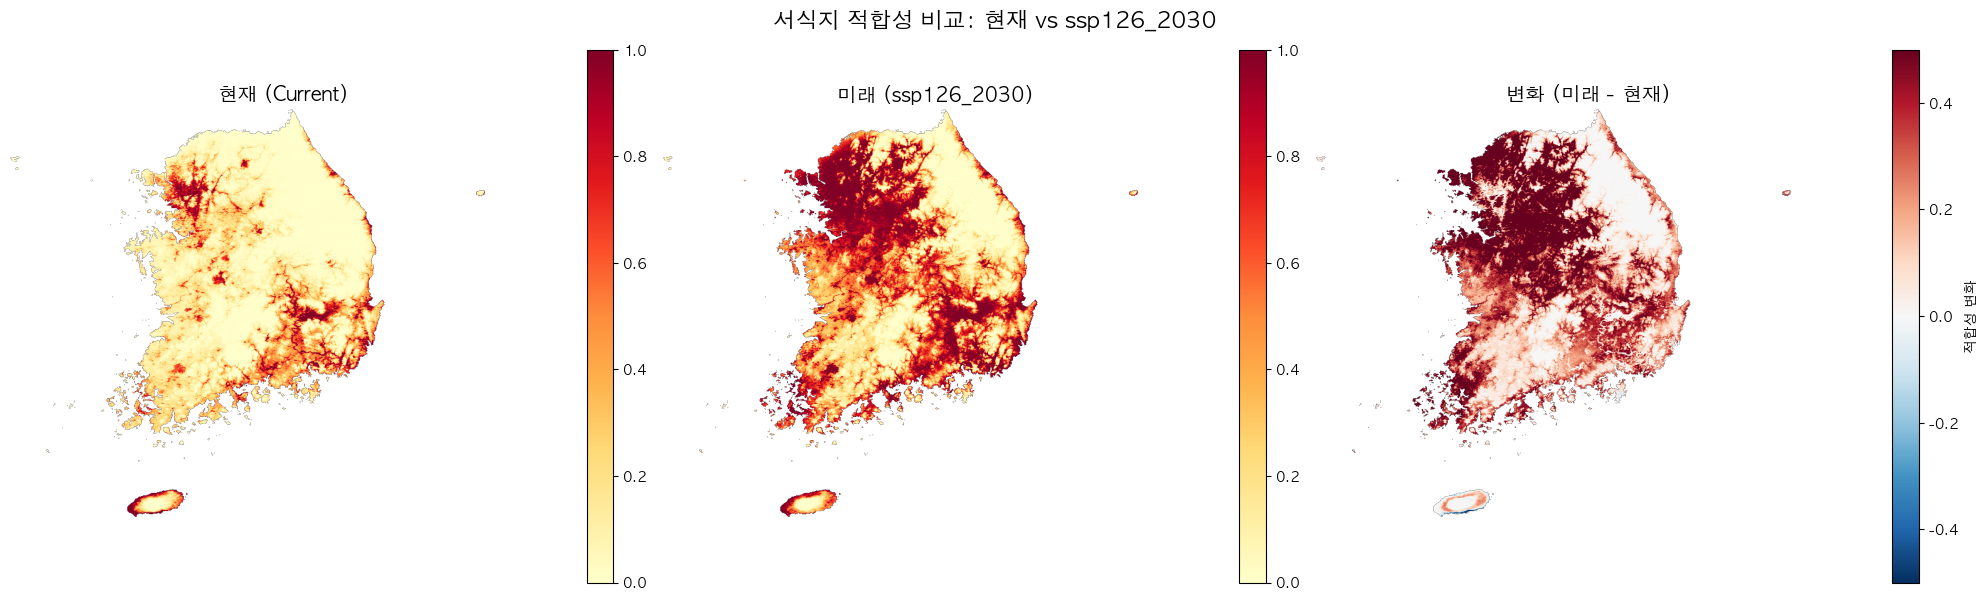


=== 변화 통계 ===
평균 변화: 0.2880
최대 증가: 0.9202
최대 감소: -0.7568

적합성 증가 지역 (>0.1): 96,328 (68.61%)
적합성 감소 지역 (<-0.1): 207 (0.15%)


=== ssp126_2050 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp126_2050.tif


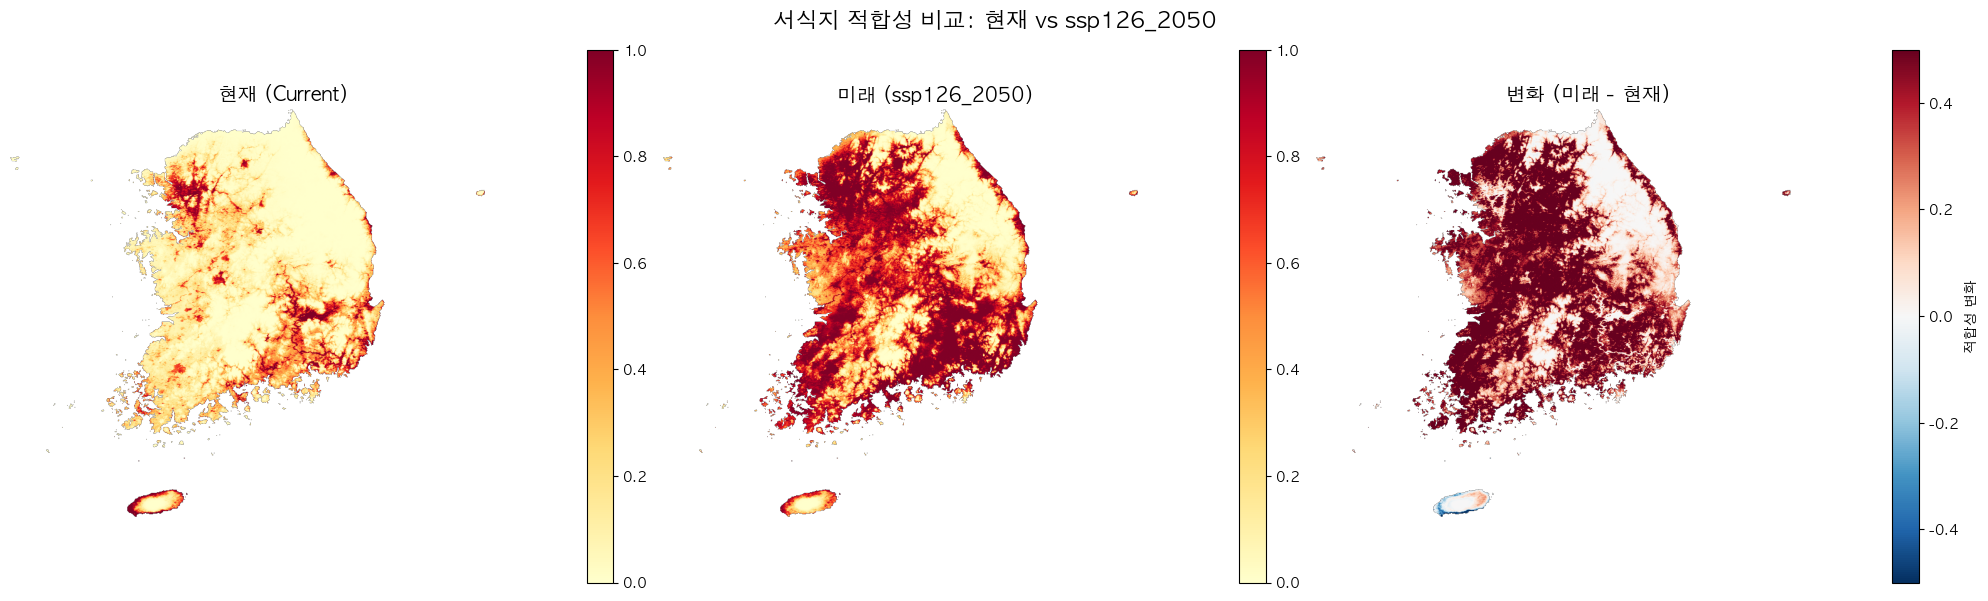


=== 변화 통계 ===
평균 변화: 0.3778
최대 증가: 0.9282
최대 감소: -0.8573

적합성 증가 지역 (>0.1): 108,713 (77.43%)
적합성 감소 지역 (<-0.1): 547 (0.39%)


=== ssp126_2070 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp126_2070.tif


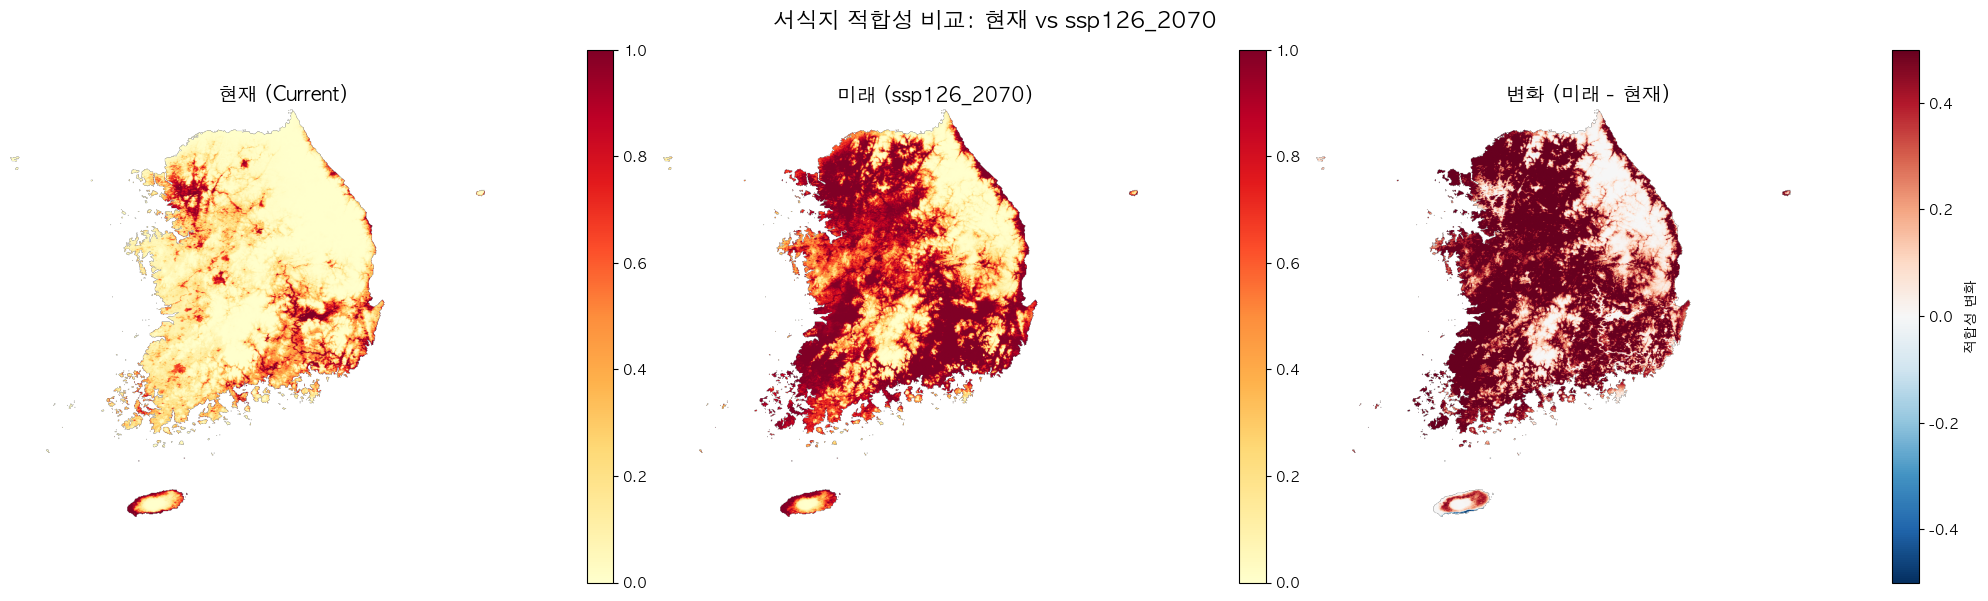


=== 변화 통계 ===
평균 변화: 0.4253
최대 증가: 0.9630
최대 감소: -0.7192

적합성 증가 지역 (>0.1): 113,563 (80.88%)
적합성 감소 지역 (<-0.1): 132 (0.09%)


=== ssp126_2090 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp126_2090.tif


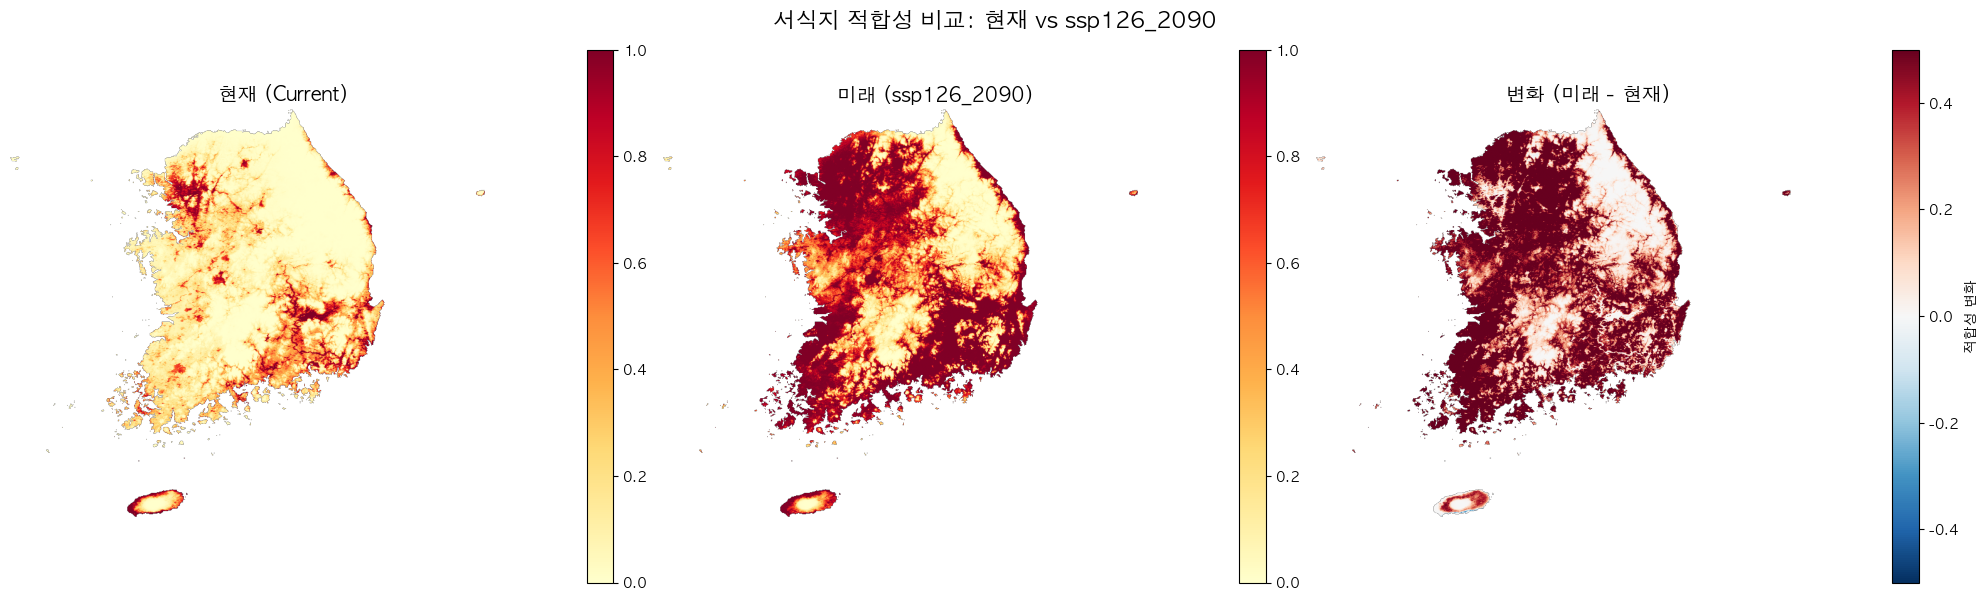


=== 변화 통계 ===
평균 변화: 0.4188
최대 증가: 0.9496
최대 감소: -0.3955

적합성 증가 지역 (>0.1): 111,980 (79.75%)
적합성 감소 지역 (<-0.1): 68 (0.05%)


=== ssp245_2030 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp245_2030.tif


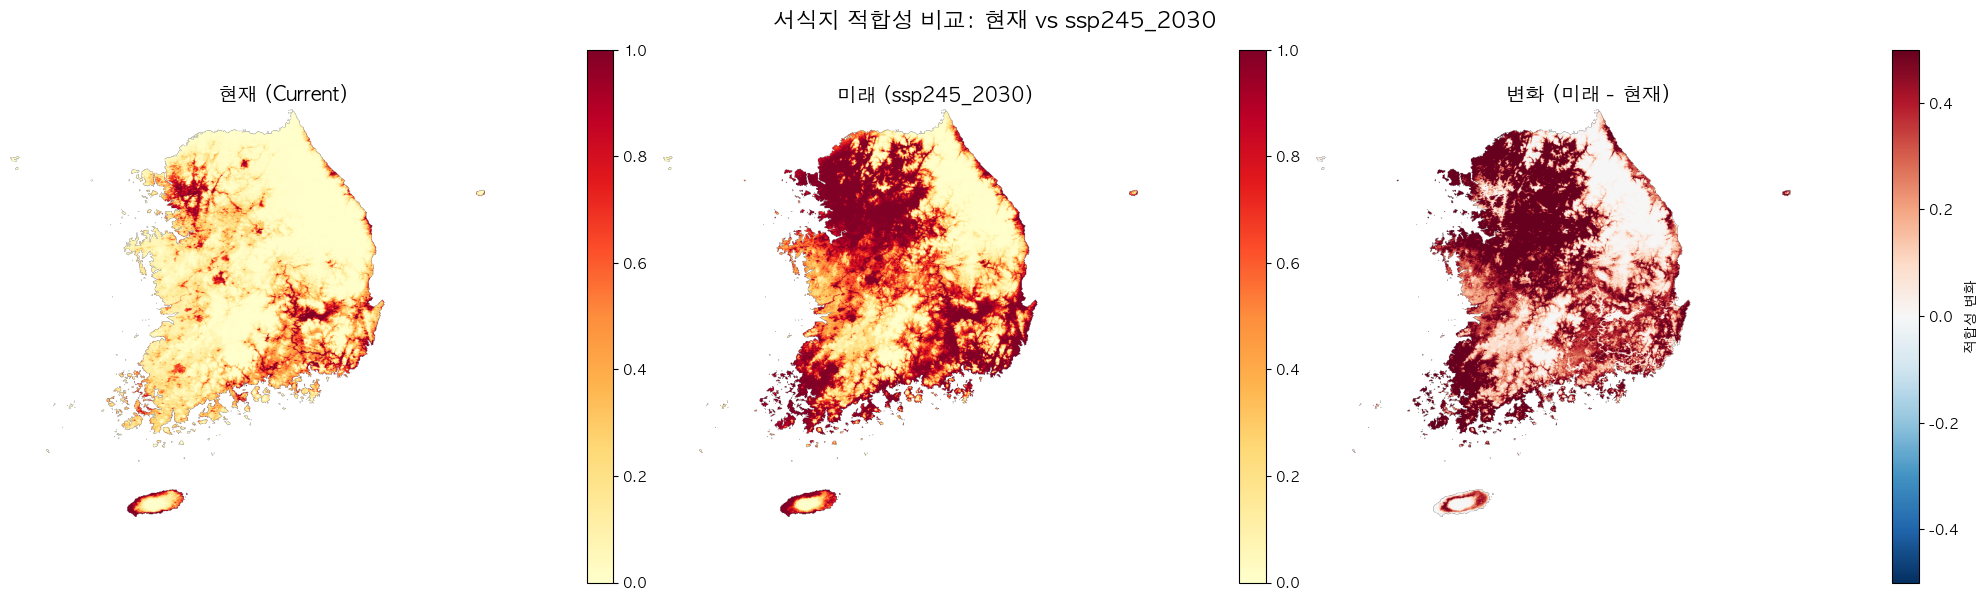


=== 변화 통계 ===
평균 변화: 0.3545
최대 증가: 0.9435
최대 감소: -0.1486

적합성 증가 지역 (>0.1): 105,673 (75.26%)
적합성 감소 지역 (<-0.1): 4 (0.00%)


=== ssp245_2050 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp245_2050.tif


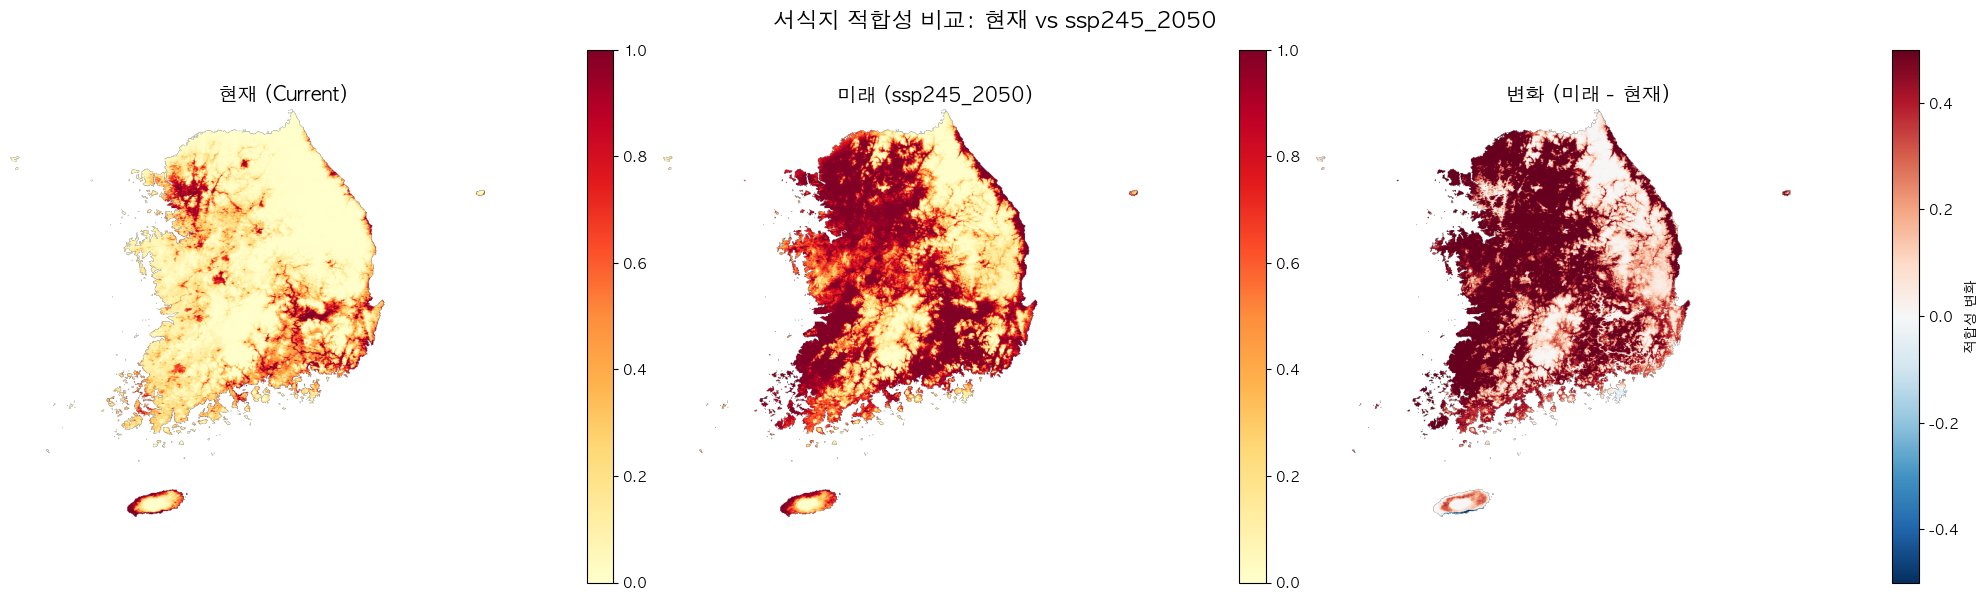


=== 변화 통계 ===
평균 변화: 0.4122
최대 증가: 0.9489
최대 감소: -0.7855

적합성 증가 지역 (>0.1): 111,911 (79.70%)
적합성 감소 지역 (<-0.1): 186 (0.13%)


=== ssp245_2070 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp245_2070.tif


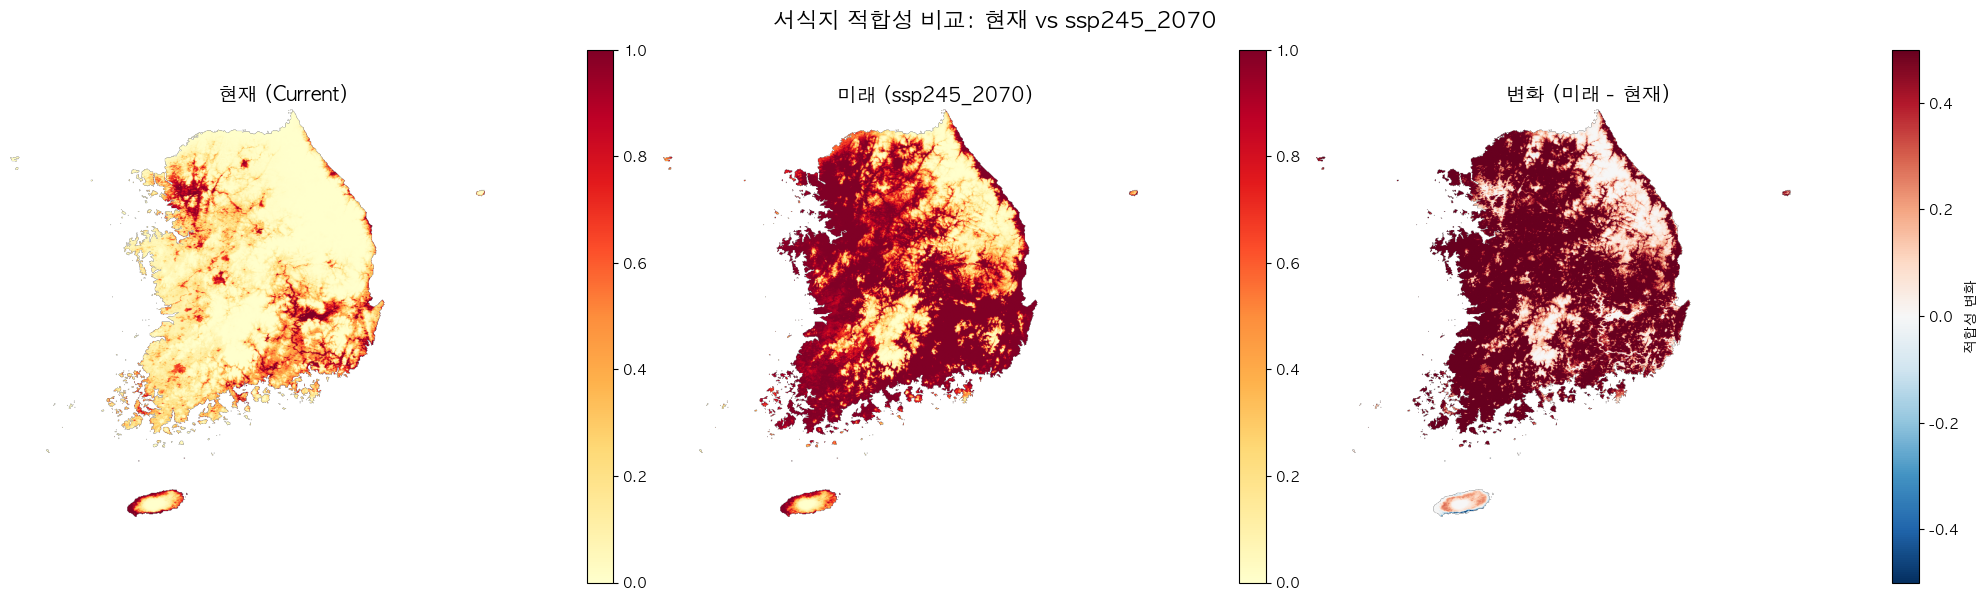


=== 변화 통계 ===
평균 변화: 0.5152
최대 증가: 0.9619
최대 감소: -0.6403

적합성 증가 지역 (>0.1): 120,359 (85.72%)
적합성 감소 지역 (<-0.1): 193 (0.14%)


=== ssp245_2090 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp245_2090.tif


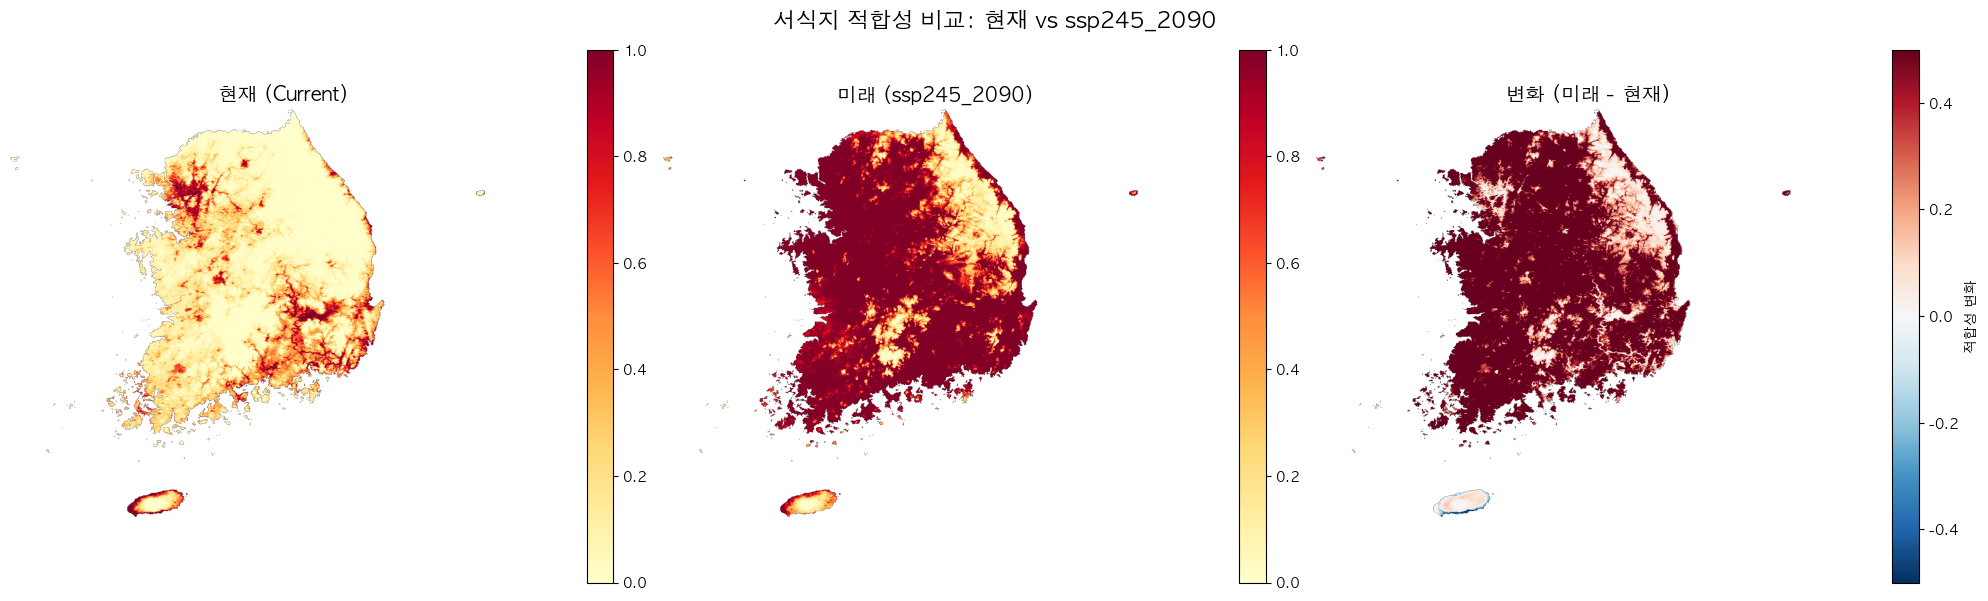


=== 변화 통계 ===
평균 변화: 0.6201
최대 증가: 0.9885
최대 감소: -0.8674

적합성 증가 지역 (>0.1): 126,305 (89.96%)
적합성 감소 지역 (<-0.1): 454 (0.32%)


=== ssp585_2030 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp585_2030.tif


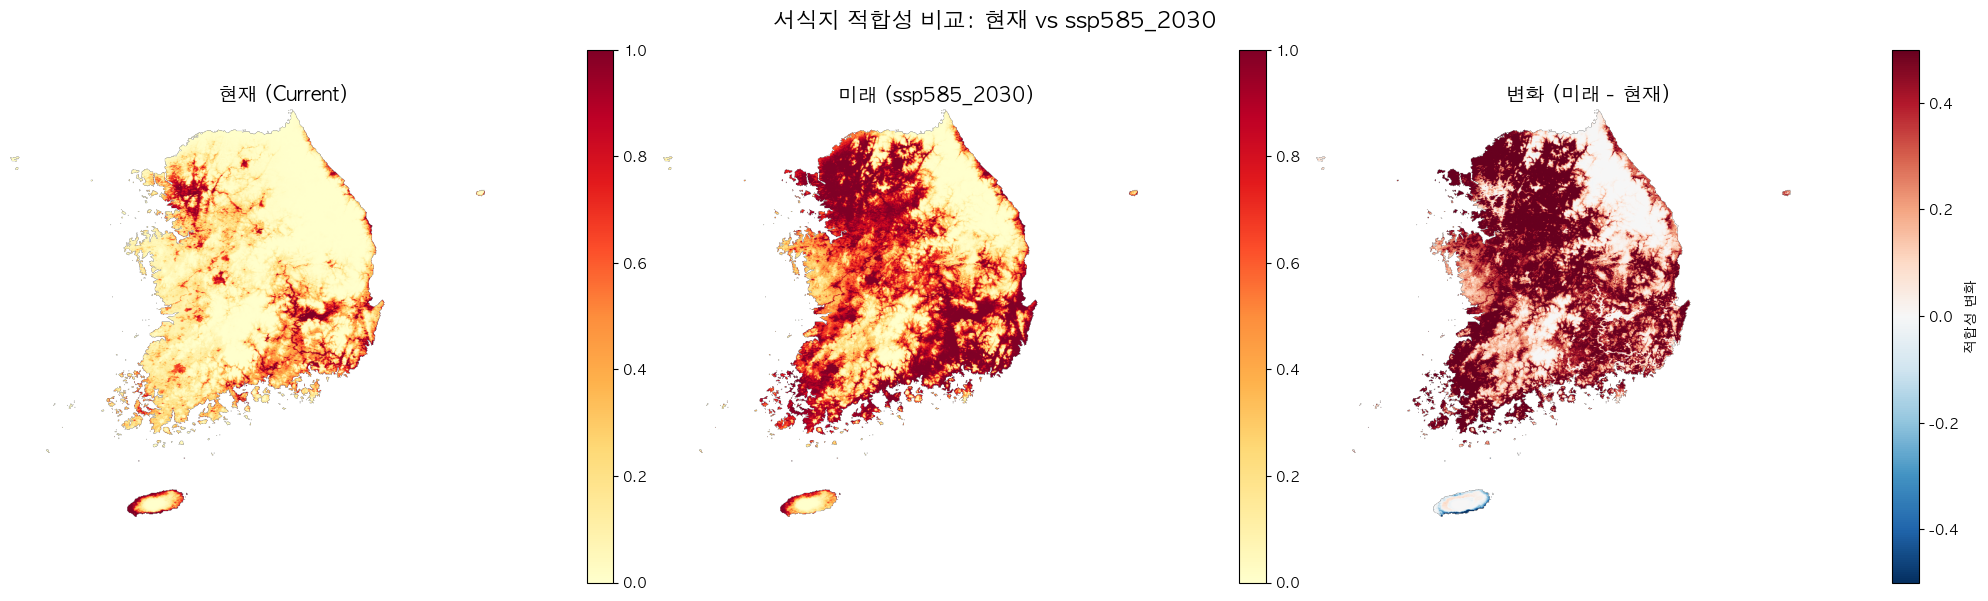


=== 변화 통계 ===
평균 변화: 0.3493
최대 증가: 0.9333
최대 감소: -0.8768

적합성 증가 지역 (>0.1): 107,434 (76.52%)
적합성 감소 지역 (<-0.1): 610 (0.43%)


=== ssp585_2050 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp585_2050.tif


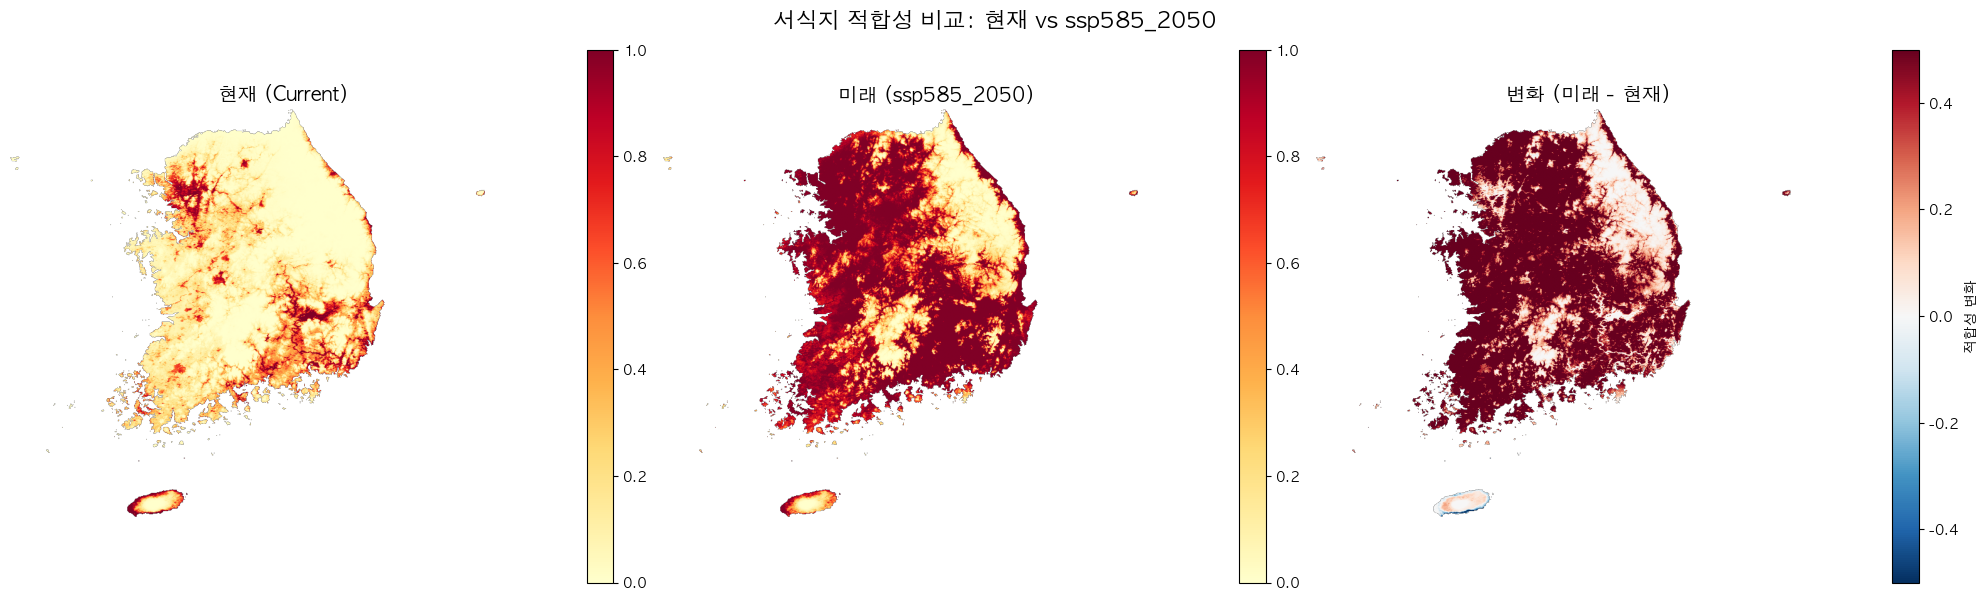


=== 변화 통계 ===
평균 변화: 0.5173
최대 증가: 0.9743
최대 감소: -0.7947

적합성 증가 지역 (>0.1): 118,207 (84.19%)
적합성 감소 지역 (<-0.1): 351 (0.25%)


=== ssp585_2070 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp585_2070.tif


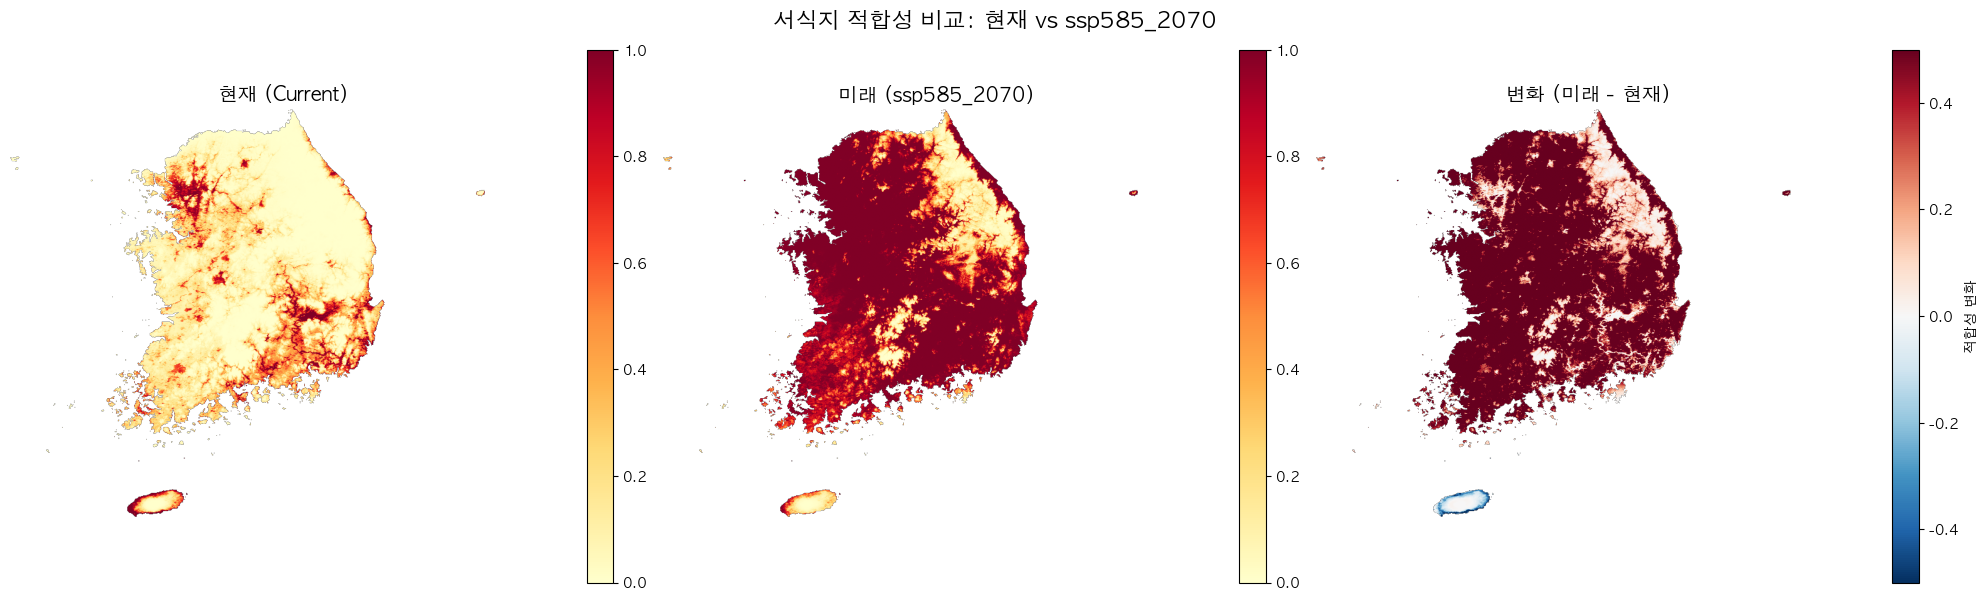


=== 변화 통계 ===
평균 변화: 0.6081
최대 증가: 0.9934
최대 감소: -0.8770

적합성 증가 지역 (>0.1): 125,242 (89.20%)
적합성 감소 지역 (<-0.1): 1,179 (0.84%)


=== ssp585_2090 시나리오 예측 ===
환경 변수 파일 수: 11
미래 환경 변수 스택 shape: (11, 660, 872)
유효한 픽셀: 140,408
미래 적합성 지도 저장 완료: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/outputs/suitability_map_ssp585_2090.tif


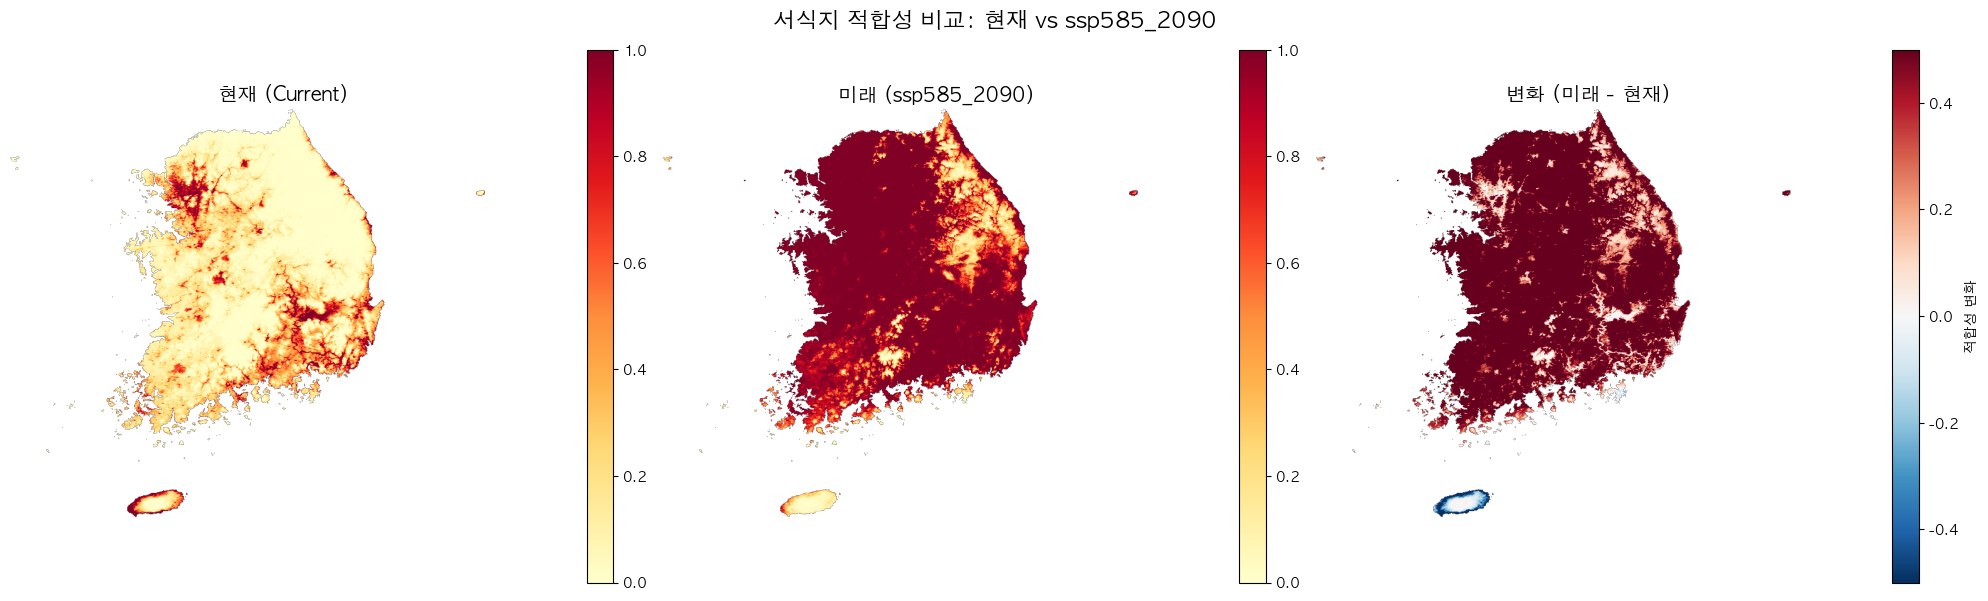


=== 변화 통계 ===
평균 변화: 0.6637
최대 증가: 0.9973
최대 감소: -0.9631

적합성 증가 지역 (>0.1): 131,335 (93.54%)
적합성 감소 지역 (<-0.1): 1,661 (1.18%)


총 12개 시나리오 예측 완료!


In [48]:
# 모든 미래 시나리오 일괄 예측 함수
def predict_all_scenarios():
    """모든 미래 시나리오에 대해 예측 수행"""
    scenarios = [
        'ssp126_2030', 'ssp126_2050', 'ssp126_2070', 'ssp126_2090',
        'ssp245_2030', 'ssp245_2050', 'ssp245_2070', 'ssp245_2090',
        'ssp585_2030', 'ssp585_2050', 'ssp585_2070', 'ssp585_2090'
    ]
    
    results = {}
    
    for scenario in scenarios:
        scenario_path = base_path / f'env/{scenario}'
        if scenario_path.exists():
            print(f"\n{'='*60}")
            future_map, diff_map = predict_future_scenario(scenario)
            if future_map is not None:
                results[scenario] = {
                    'suitability_map': future_map,
                    'difference_map': diff_map
                }
        else:
            print(f"\n경고: {scenario} 데이터를 찾을 수 없습니다. 건너뜁니다.")
    
    print(f"\n\n총 {len(results)}개 시나리오 예측 완료!")
    return results

# 사용 예제 (주석 제거 후 실행 - 시간이 오래 걸릴 수 있음)
all_results = predict_all_scenarios()